In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load preprocessed data
data_dir = '../data/processed/'

X_train = pd.read_csv(data_dir + 'X_train.csv').to_numpy()
X_val = pd.read_csv(data_dir + 'X_val.csv').to_numpy()
X_test = pd.read_csv(data_dir + 'X_test.csv').to_numpy()

y_train = pd.read_csv(data_dir + 'y_train.csv').to_numpy().flatten()
y_val = pd.read_csv(data_dir + 'y_val.csv').to_numpy().flatten()
y_test = pd.read_csv(data_dir + 'y_test.csv').to_numpy().flatten()

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training Y shape: {y_train.shape}")
print(f"\nClass distribution in training set:")
print(f"  Existing Customer (0): {(y_train == 0).sum()}")
print(f"  Attrited Customer (1): {(y_train == 1).sum()}")

Training set shape: (11898, 22)
Validation set shape: (1519, 22)
Test set shape: (1520, 22)
Training Y shape: (11898,)

Class distribution in training set:
  Existing Customer (0): 5949
  Attrited Customer (1): 5949


In [9]:
# Logistic Regression Model
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION (No Transformation)")
print("=" * 60)

lr = LogisticRegression(max_iter=1000, random_state=67)
lr.fit(X_train, y_train)

# Predictions on all sets
y_train_pred_lr = lr.predict(X_train)
y_val_pred_lr = lr.predict(X_val)
y_test_pred_lr = lr.predict(X_test)

# Get probability predictions for ROC-AUC
y_train_pred_proba_lr = lr.predict_proba(X_train)[:, 1]
y_val_pred_proba_lr = lr.predict_proba(X_val)[:, 1]
y_test_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# Evaluate on Training Set
print("\nTraining Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_pred_proba_lr):.4f}")

# Evaluate on Validation Set
print("\nValidation Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_val_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_val, y_val_pred_proba_lr):.4f}")

# Evaluate on Test Set
print("\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba_lr):.4f}")


LOGISTIC REGRESSION (No Transformation)

Training Set Performance:
  Accuracy:  0.8622
  Precision: 0.8577
  Recall:    0.8685
  F1-Score:  0.8631
  ROC-AUC:   0.9353

Validation Set Performance:
  Accuracy:  0.8545
  Precision: 0.5291
  Recall:    0.8566
  F1-Score:  0.6541
  ROC-AUC:   0.9274

Test Set Performance:
  Accuracy:  0.8467
  Precision: 0.5152
  Recall:    0.7664
  F1-Score:  0.6161
  ROC-AUC:   0.9073


In [10]:
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0]

from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
import numpy as np

transformations = [
    {'name': 'No Transformation', 'transform': lambda X: X},
    {'name': 'Poly Degree 2', 'transform': lambda X: PolynomialFeatures(degree=2, include_bias=False).fit_transform(X)},
    {'name': 'Poly Degree 3', 'transform': lambda X: PolynomialFeatures(degree=3, include_bias=False).fit_transform(X)},
    # {'name': 'Poly Degree 4', 'transform': lambda X: PolynomialFeatures(degree=4, include_bias=False).fit_transform(X)},
    {'name': 'Logarithmic', 'transform': lambda X: FunctionTransformer(lambda Y: np.hstack((Y, np.sign(Y) * np.log1p(np.abs(Y)))), validate=True).fit_transform(X)},
]

results = []

for trans in transformations:
    print(f"\nProcessing transformation: {trans['name']}")
    X_train_t = trans['transform'](X_train)
    X_val_t = trans['transform'](X_val)
    # X_test_t = trans['transform'](X_test)
    
    # print(f"  Transformed shapes: Train {X_train_t.shape}, Val {X_val_t.shape}, Test {X_test_t.shape}")
    print(f"  Transformed shapes: Train {X_train_t.shape}, Val {X_val_t.shape}")
    
    for lam in lambda_values:
        if lam == 0:
            C = 1e6  # High C for no regularization
        else:
            C = 1 / lam
        
        # Create logistic regression model
        lr_model = LogisticRegression(C=C, max_iter=1000, random_state=67)
        lr_model.fit(X_train_t, y_train)
        
        # Predictions
        y_train_pred = lr_model.predict(X_train_t)
        y_val_pred = lr_model.predict(X_val_t)
        # y_test_pred = lr_model.predict(X_test_t)
        
        y_train_proba = lr_model.predict_proba(X_train_t)[:, 1]
        y_val_proba = lr_model.predict_proba(X_val_t)[:, 1]
        # y_test_proba = lr_model.predict_proba(X_test_t)[:, 1]
        
        # Metrics for each dataset
        # for dataset, y_true, y_pred, y_proba in [('train', y_train, y_train_pred, y_train_proba),
        #                                          ('val', y_val, y_val_pred, y_val_proba),
        #                                          ('test', y_test, y_test_pred, y_test_proba)]:
        for dataset, y_true, y_pred, y_proba in [('train', y_train, y_train_pred, y_train_proba),
                                                 ('val', y_val, y_val_pred, y_val_proba)]:
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc = roc_auc_score(y_true, y_proba)
            
            results.append({
                'transformation': trans['name'],
                'lambda': lam,
                'C': C,
                'dataset': dataset,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'roc_auc': roc
            })

# Create DataFrame
results_df = pd.DataFrame(results)

# Display results
print("\nLogistic Regression Performance Results:")
print("=" * 80)
for trans_name in results_df['transformation'].unique():
    print(f"\n{trans_name}")
    print("-" * 40)
    trans_df = results_df[results_df['transformation'] == trans_name]
    for lam in lambda_values:
        print(f"\nLambda = {lam} (C = {trans_df[trans_df['lambda'] == lam]['C'].iloc[0]:.6f})")
        lam_df = trans_df[trans_df['lambda'] == lam]
        for _, row in lam_df.iterrows():
            print(f"  {row['dataset'].capitalize()} Set: Acc={row['accuracy']:.4f}, Prec={row['precision']:.4f}, Rec={row['recall']:.4f}, F1={row['f1']:.4f}, ROC-AUC={row['roc_auc']:.4f}")


Processing transformation: No Transformation
  Transformed shapes: Train (11898, 22), Val (1519, 22)

Processing transformation: Poly Degree 2
  Transformed shapes: Train (11898, 275), Val (1519, 275)

Processing transformation: Poly Degree 3
  Transformed shapes: Train (11898, 2299), Val (1519, 2299)

Processing transformation: Logarithmic
  Transformed shapes: Train (11898, 44), Val (1519, 44)

Logistic Regression Performance Results:

No Transformation
----------------------------------------

Lambda = 0 (C = 1000000.000000)
  Train Set: Acc=0.8622, Prec=0.8579, Rec=0.8684, F1=0.8631, ROC-AUC=0.9353
  Val Set: Acc=0.8545, Prec=0.5291, Rec=0.8566, F1=0.6541, ROC-AUC=0.9274

Lambda = 1e-05 (C = 100000.000000)
  Train Set: Acc=0.8622, Prec=0.8579, Rec=0.8684, F1=0.8631, ROC-AUC=0.9353
  Val Set: Acc=0.8545, Prec=0.5291, Rec=0.8566, F1=0.6541, ROC-AUC=0.9274

Lambda = 0.0001 (C = 10000.000000)
  Train Set: Acc=0.8622, Prec=0.8579, Rec=0.8684, F1=0.8631, ROC-AUC=0.9353
  Val Set: Acc=0.

Best model: poly degree 2 lambda=0.0001

In [13]:
lambda_values = [0.0001]

from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
import numpy as np

transformations = [
    {'name': 'Poly Degree 2', 'transform': lambda X: PolynomialFeatures(degree=2, include_bias=False).fit_transform(X)}
]

test_results = []

for trans in transformations:
    print(f"\nProcessing transformation: {trans['name']}")
    X_train_t = trans['transform'](X_train)
    X_test_t = trans['transform'](X_test)
    
    print(f"  Transformed shapes: Test {X_test_t.shape}")
    
    for lam in lambda_values:
        C = 1 / lam
        
        # Create logistic regression model
        lr_model = LogisticRegression(C=C, max_iter=1000, random_state=67)
        lr_model.fit(X_train_t, y_train)
        
        # Predictions
        # y_train_pred = lr_model.predict(X_train_t)
        # y_val_pred = lr_model.predict(X_val_t)
        y_test_pred = lr_model.predict(X_test_t)
        
        # y_train_proba = lr_model.predict_proba(X_train_t)[:, 1]
        # y_val_proba = lr_model.predict_proba(X_val_t)[:, 1]
        y_test_proba = lr_model.predict_proba(X_test_t)[:, 1]
        
        # Metrics for each dataset
        # for dataset, y_true, y_pred, y_proba in [('train', y_train, y_train_pred, y_train_proba),
        #                                          ('val', y_val, y_val_pred, y_val_proba),
        #                                          ('test', y_test, y_test_pred, y_test_proba)]:
        for dataset, y_true, y_pred, y_proba in [('test', y_test, y_test_pred, y_test_proba)]:
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc = roc_auc_score(y_true, y_proba)
            
            test_results.append({
                'transformation': trans['name'],
                'lambda': lam,
                'C': C,
                'dataset': dataset,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'roc_auc': roc
            })

# Create DataFrame
test_results_df = pd.DataFrame(test_results)

# Display results
print("\nLogistic Regression Performance Results:")
print("=" * 80)
for trans_name in test_results_df['transformation'].unique():
    print(f"\n{trans_name}")
    print("-" * 40)
    trans_df = test_results_df[test_results_df['transformation'] == trans_name]
    for lam in lambda_values:
        print(f"\nLambda = {lam} (C = {trans_df[trans_df['lambda'] == lam]['C'].iloc[0]:.6f})")
        lam_df = trans_df[trans_df['lambda'] == lam]
        for _, row in lam_df.iterrows():
            print(f"  {row['dataset'].capitalize()} Set: Acc={row['accuracy']:.4f}, Prec={row['precision']:.4f}, Rec={row['recall']:.4f}, F1={row['f1']:.4f}, ROC-AUC={row['roc_auc']:.4f}")


Processing transformation: Poly Degree 2
  Transformed shapes: Test (1520, 275)

Logistic Regression Performance Results:

Poly Degree 2
----------------------------------------

Lambda = 0.0001 (C = 10000.000000)
  Test Set: Acc=0.9211, Prec=0.7441, Rec=0.7746, F1=0.7590, ROC-AUC=0.9501


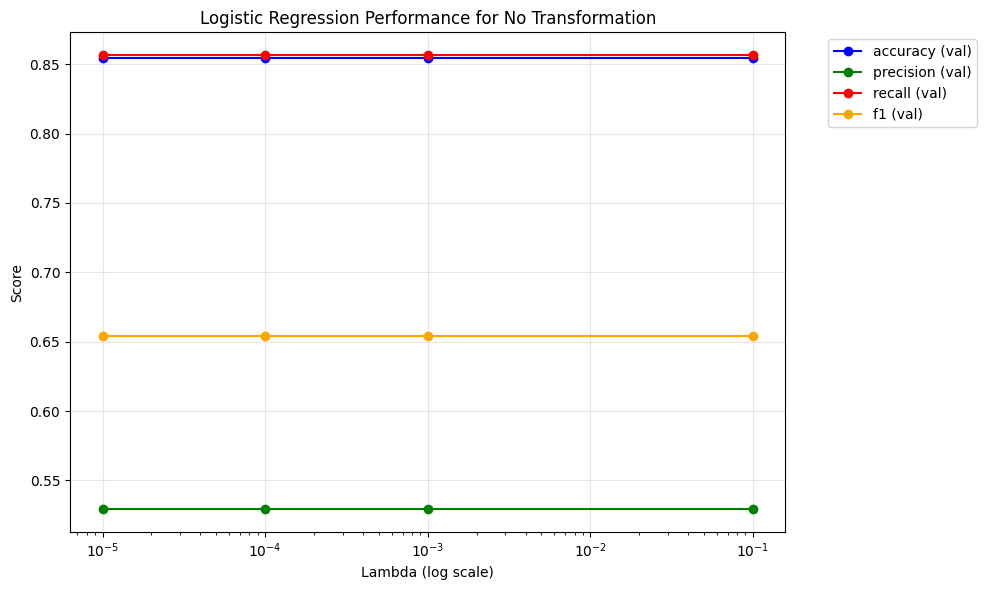

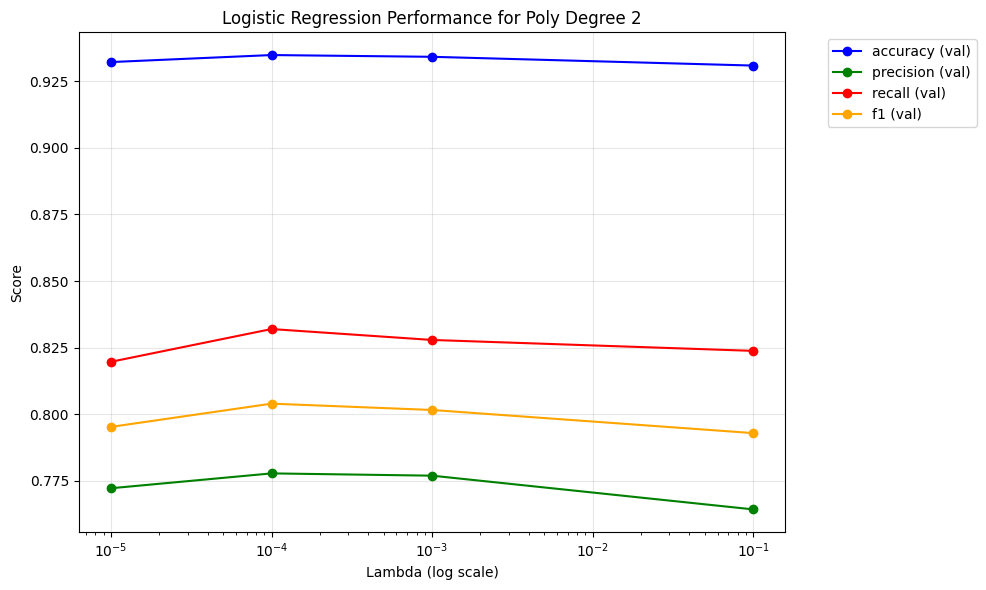

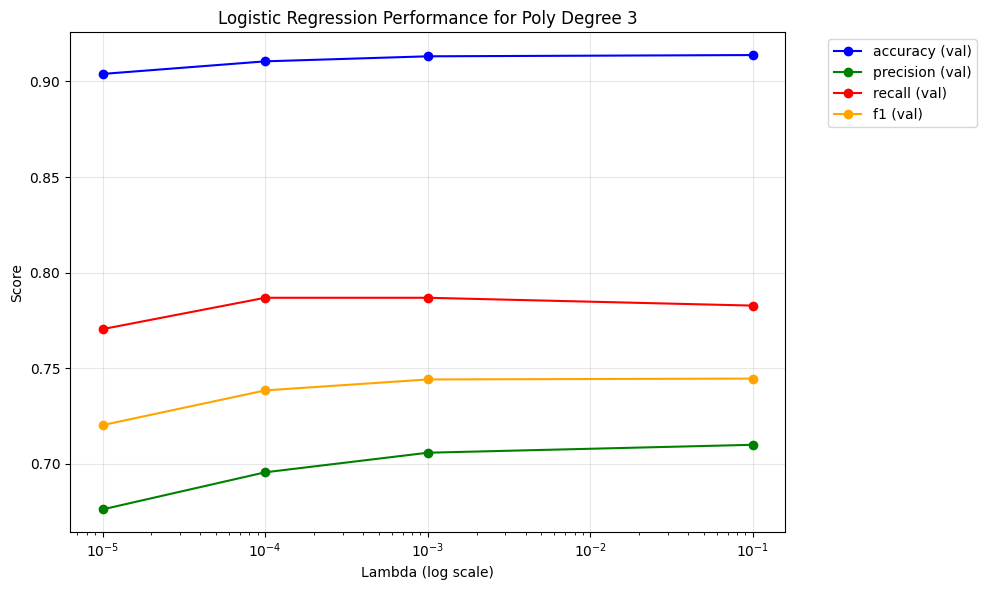

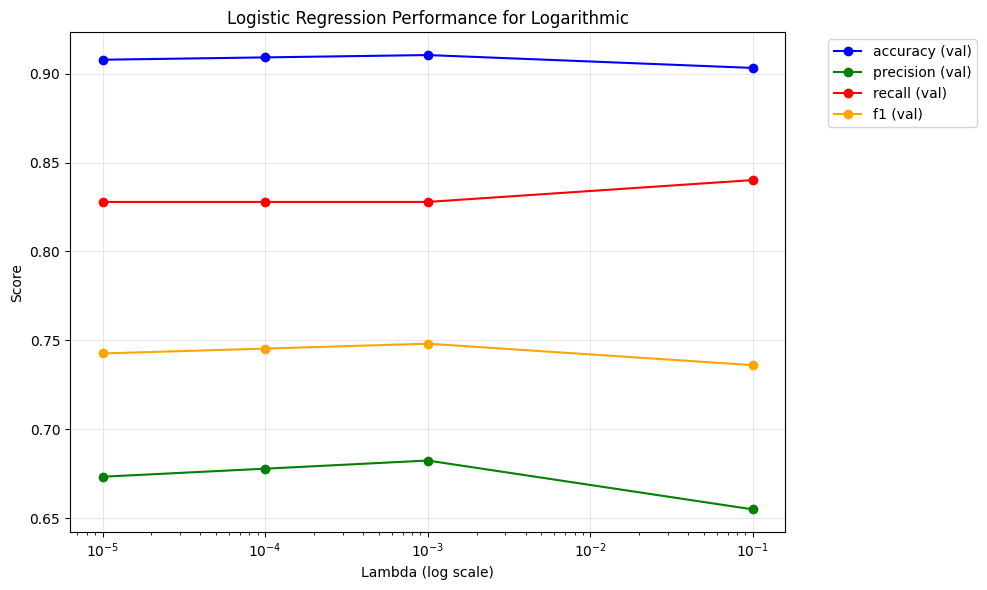

In [12]:
import matplotlib.pyplot as plt

# Plot performance for each transformation
for trans_name in results_df['transformation'].unique():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    trans_df = results_df[results_df['transformation'] == trans_name]
    
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    # datasets = ['train', 'val', 'test']
    datasets = ['val']
    
    # Define line styles and colors
    line_styles = ['-', '--', '-.', ':']
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    
    for i, metric in enumerate(metrics):
        for j, dataset in enumerate(datasets):
            sub_df = trans_df[(trans_df['dataset'] == dataset) & (trans_df['lambda'] > 0)].sort_values('lambda')  # Exclude lambda=0 for log scale
            if not sub_df.empty:
                ax.plot(sub_df['lambda'][:-2], sub_df[metric][:-2], 
                       label=f'{metric} ({dataset})', 
                       color=colors[i], 
                       linestyle=line_styles[j],
                       marker='o')
    
    ax.set_xlabel('Lambda (log scale)')
    ax.set_ylabel('Score')
    ax.set_title(f'Logistic Regression Performance for {trans_name}')
    ax.set_xscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()